# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful **starting points** for the extension include:_

* **Stereo view synthesis:** Start from a **dense disparity map** (e.g. the motorcycle stereo pair in Part 2) and aim to **draw the scene again** as if a **second, shifted camera** had taken the picture- not just a false-color disparity plot.

* **Metric depth:** Turn disparities into **metric depth** with $\text{depth} = \frac{B \cdot f}{\text{disparity}}$ using a plausible **baseline** and **focal length**, and stabilize the denominator when disparity is tiny or noisy.

* **Calibration & lifting:** Use the camera **intrinsics** ($3 \times 3$ matrix $K$) together with disparity and baseline to **lift pixels from the image into 3D** in the original camera’s coordinate frame.

* **Virtual camera motion:** Describe how the new camera sits relative to the first with a **rigid motion**—a **rotation** and **translation**—and **move every 3D point** into that new camera’s frame before drawing.

* **Rendering:** **Project** those 3D points back onto a **fresh image grid** with intrinsics suited to the new view, producing the **rerendered photograph** (including how you handle resolution, bounds, and empty pixels).

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: David Lowe, “Distinctive Image Features from Scale-Invariant Keypoints” (2004)- https://link.springer.com/article/10.1023/B:VISI.0000029664.99615.94
This paper introduces SIFT and the ratio test used in feature matching. It shows how comparing nearest neighbors helps filter incorrect matches. This supports my experiment on how the ratio threshold affects matching results.
* Source 2: David Lowe, “Automatic Panoramic Image Stitching using Invariant Features" (2006)- https://link.springer.com/article/10.1007/s11263-006-0002-3
This paper demonstrates how Lowe’s ratio test is used to filter matches in panorama stitching. It shows that removing ambiguous matches is essential for accurate alignment. This inspired my exploration of how changing the ratio threshold affects matching performance.
* Source 3: OpenCV Feature Matching Tutorial-https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
This tutorial shows how feature matching is implemented in practice using nearest neighbors and Lowe’s ratio test. It explains how to use two nearest matches (k=2) and filter them based on a threshold. This connects directly to how the ratio test is applied in real computer vision systems.

* Source 4: Brown, Szeliski, and Winder, “Multi-Image Matching using Multi-Scale Oriented Patches” (2005)
This paper presents an alternative feature descriptor (MOPS) and discusses feature matching performance across images. It highlights the importance of reliable matching criteria and compares different approaches to filtering matches. This provides context for why techniques like the ratio test are necessary for reducing incorrect correspondences.

* Source 5: Roboflow Blog – “What is Feature Matching?” – https://blog.roboflow.com/what-is-feature-matching/
This tutorial provides an intuitive explanation of feature matching and why filtering is needed. It explains that if the closest and second-closest matches are too similar, the match is likely unreliable, which is exactly what the ratio test captures. It also discusses how the threshold controls the trade-off between match quality and quantity.


## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You are not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [7]:
import os

if not os.path.exists("CS131_release"):
    !git clone https://github.com/aarav06-bit/CS131_release.git

%cd /content/CS131_release/spring_2026/project2_release/option_B

/content/CS131_release/spring_2026/project2_release/option_B


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.feature import corner_peaks
from scipy.spatial.distance import cdist
from scipy.ndimage import convolve
from skimage import filters

from utils import pad, unpad, get_output_space, warp_image, plot_matches, describe_keypoints



In [9]:
def harris_corners(img, window_size=3, k=0.04):

    H, W = img.shape
    window = np.ones((window_size, window_size))

    response = np.zeros((H, W))
    dx = filters.sobel_v(img)
    dy = filters.sobel_h(img)

    Ixx = dx * dx
    Iyy = dy * dy
    Ixy = dx * dy

    Sxx = convolve(Ixx, window, mode='constant', cval=0)
    Syy = convolve(Iyy, window, mode='constant', cval=0)
    Sxy = convolve(Ixy, window, mode='constant', cval=0)

    det_M = Sxx * Syy - Sxy * Sxy
    trace_M = Sxx + Syy

    response = det_M - k * (trace_M ** 2)

    return response

def simple_descriptor(patch):

    feature = []

    mean = np.mean(patch)
    std = np.std(patch)
    if std == 0:
        std = 1
    feature = ((patch - mean) / std).flatten()

    return feature

def match_descriptors(desc1, desc2, threshold=0.5):

    matches = []

    M = desc1.shape[0]
    dists = cdist(desc1, desc2)

    for i in range(M):
        row = dists[i]
        sorted_indices = np.argsort(row)
        closest_idx = sorted_indices[0]
        second_closest_idx = sorted_indices[1]

        if row[closest_idx] / row[second_closest_idx] < threshold:
            matches.append([i, closest_idx])

    matches = np.asarray(matches)

    return matches


In [10]:
def fit_affine_matrix(p1, p2, to_pad=True):
    assert (p1.shape[0] == p2.shape[0])
    if to_pad:
        p1 = pad(p1)
        p2 = pad(p2)
    H, _, _, _ = np.linalg.lstsq(p2, p1, rcond=None)
    H[:, 2] = np.array([0, 0, 1])
    return H

In [11]:
def ransac(keypoints1, keypoints2, matches, n_iters=200, threshold=20):
    orig_matches = matches.copy()
    matches = matches.copy()
    N = matches.shape[0]
    n_samples = max(3, int(N * 0.2))
    matched1 = pad(keypoints1[matches[:, 0]])
    matched2 = pad(keypoints2[matches[:, 1]])
    max_inliers = np.zeros(N, dtype=bool)
    n_inliers = 0
    for i in range(n_iters):
        np.random.shuffle(matches)
        samples = matches[:n_samples]
        unique_pts = np.unique(keypoints2[samples[:, 1]], axis=0)
        if len(unique_pts) < 3:
            continue
        sample1 = pad(keypoints1[samples[:, 0]])
        sample2 = pad(keypoints2[samples[:, 1]])
        if np.linalg.matrix_rank(sample2) < 3:
            continue
        H = fit_affine_matrix(sample1, sample2, to_pad=False)
        predicted = matched2 @ H
        distances = np.linalg.norm(predicted - matched1, axis=1)
        inliers = distances < threshold
        n_curr_inliers = np.sum(inliers)
        if n_curr_inliers > n_inliers:
            n_inliers = n_curr_inliers
            max_inliers = inliers
    if max_inliers.sum() >= 3:
        H = fit_affine_matrix(matched1[max_inliers], matched2[max_inliers], to_pad=False)
    else:
        H = np.eye(3)
    return H, orig_matches[max_inliers]

In [12]:
def linear_blend(img1_warped, img2_warped):
    out_H, out_W = img1_warped.shape
    img1_mask = (img1_warped != 0)
    img2_mask = (img2_warped != 0)
    right_margin = out_W - np.argmax(np.fliplr(img1_mask)[out_H//2, :].reshape(1, out_W), 1)[0]
    left_margin = np.argmax(img2_mask[out_H//2, :].reshape(1, out_W), 1)[0]
    weights1 = np.ones((out_H, out_W))
    weights1[:, left_margin:right_margin] = np.linspace(1, 0, right_margin - left_margin)
    weights1[:, right_margin:] = 0
    weights2 = np.zeros((out_H, out_W))
    weights2[:, left_margin:right_margin] = np.linspace(0, 1, right_margin - left_margin)
    weights2[:, right_margin:] = 1
    weights1 = weights1 * img1_mask
    weights2 = weights2 * img2_mask
    merged = img1_warped * weights1 + img2_warped * weights2
    return merged

In [13]:
def fit_homography_matrix(p1, p2):
    N = p1.shape[0]
    A = np.zeros((2 * N, 9))
    for i in range(N):
        x, y = p2[i]
        x_prime, y_prime = p1[i]
        A[2*i]     = [-x, -y, -1,  0,  0,  0, x*x_prime, y*x_prime, x_prime]
        A[2*i + 1] = [ 0,  0,  0, -x, -y, -1, x*y_prime, y*y_prime, y_prime]
    _, _, V = np.linalg.svd(A)
    H = V[-1].reshape(3, 3)
    return H / H[2, 2]

In [14]:
def ransac_homography(keypoints1, keypoints2, matches, n_iters=500, threshold=5):
    matches = matches.copy()
    N = matches.shape[0]
    pts1 = keypoints1[matches[:, 0]][:, ::-1].astype(np.float64)
    pts2 = keypoints2[matches[:, 1]][:, ::-1].astype(np.float64)
    max_inliers = np.zeros(N, dtype=bool)
    n_inliers = 0
    for _ in range(n_iters):
        if N < 4:
            break
        idx = np.random.choice(N, 4, replace=False)
        unique_pts = np.unique(pts2[idx], axis=0)
        if len(unique_pts) < 4:
            continue
        H = fit_homography_matrix(pts1[idx], pts2[idx])
        pts2_h = np.hstack([pts2, np.ones((N, 1))])
        projected = (H @ pts2_h.T).T
        denom = projected[:, 2:3]
        if np.any(np.abs(denom) < 1e-10):
            continue
        projected = projected[:, :2] / denom
        distances = np.linalg.norm(projected - pts1, axis=1)
        inliers = distances < threshold
        if inliers.sum() > n_inliers:
            n_inliers = inliers.sum()
            max_inliers = inliers
    if n_inliers >= 4:
        H = fit_homography_matrix(pts1[max_inliers], pts2[max_inliers])
    else:
        H = np.eye(3)
    return H

In [15]:
def stitch_with_affine(img1, img2):
    if len(img1.shape) == 3:
        img1 = color.rgb2gray(img1)
    if len(img2.shape) == 3:
        img2 = color.rgb2gray(img2)
    kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
    kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)
    desc1 = describe_keypoints(img1, kpts1, desc_func=simple_descriptor, patch_size=16)
    desc2 = describe_keypoints(img2, kpts2, desc_func=simple_descriptor, patch_size=16)
    matches = match_descriptors(desc1, desc2, threshold=0.7)
    H, _ = ransac(kpts1, kpts2, matches, threshold=2)
    output_shape, offset = get_output_space(img1, [img2], [H])
    img1_warped = warp_image(img1, np.eye(3), output_shape, offset)
    img1_warped[img1_warped == -1] = 0
    img2_warped = warp_image(img2, H, output_shape, offset)
    img2_warped[img2_warped == -1] = 0
    return linear_blend(img1_warped, img2_warped)

In [16]:
def stitch_with_homography(img1, img2):
    if len(img1.shape) == 3:
        img1 = color.rgb2gray(img1)
    if len(img2.shape) == 3:
        img2 = color.rgb2gray(img2)
    kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
    kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)
    desc1 = describe_keypoints(img1, kpts1, desc_func=simple_descriptor, patch_size=16)
    desc2 = describe_keypoints(img2, kpts2, desc_func=simple_descriptor, patch_size=16)
    matches = match_descriptors(desc1, desc2, threshold=0.7)
    H_xy = ransac_homography(kpts1, kpts2, matches, threshold=5)
    H_yx = np.array([[H_xy[1, 1], H_xy[1, 0], H_xy[1, 2]],
                     [H_xy[0, 1], H_xy[0, 0], H_xy[0, 2]],
                     [H_xy[2, 1], H_xy[2, 0], H_xy[2, 2]]]).T
    output_shape, offset = get_output_space(img1, [img2], [H_yx])
    img1_warped = warp_image(img1, np.eye(3), output_shape, offset)
    img1_warped[img1_warped == -1] = 0
    img2_warped = warp_image(img2, H_yx, output_shape, offset)
    img2_warped[img2_warped == -1] = 0
    return linear_blend(img1_warped, img2_warped)

In [17]:
image_sets = [
    ("/content/goku1.jpg",    "/content/goku2.jpg"),
    ("/content/blanket1.jpg", "/content/blanket2.jpg"),
    ("/content/hallway1.jpg", "/content/hallway2.jpg"),
]

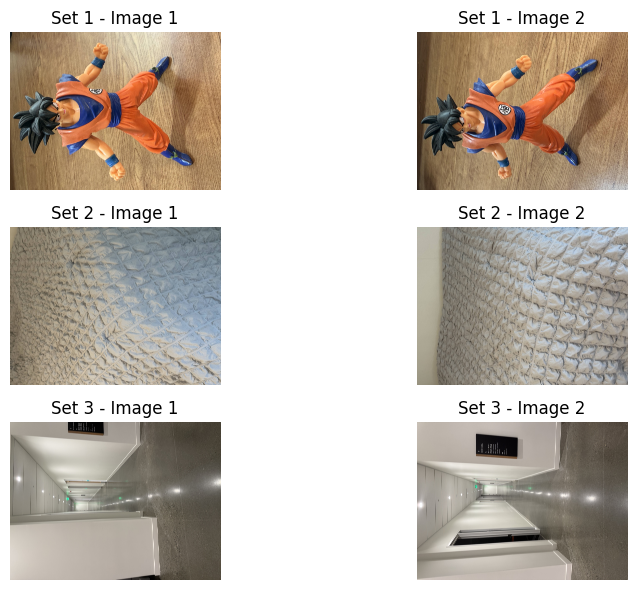

In [ ]:
def show_original_images(image_sets):
    plt.figure(figsize=(10, 6))

    for i, (p1, p2) in enumerate(image_sets):
        img1 = io.imread(p1)
        img2 = io.imread(p2)

        plt.subplot(len(image_sets), 2, 2*i + 1)
        plt.imshow(img1)
        plt.title(f"Set {i+1} - Image 1")
        plt.axis('off')

        plt.subplot(len(image_sets), 2, 2*i + 2)
        plt.imshow(img2)
        plt.title(f"Set {i+1} - Image 2")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
show_original_images(image_sets)

plt.figure(figsize=(14, 5 * len(image_sets)))

for i, (p1, p2) in enumerate(image_sets):
    img1 = io.imread(p1)
    img2 = io.imread(p2)

    np.random.seed(131)
    pano_affine = stitch_with_affine(img1, img2)

    np.random.seed(131)
    pano_homography = stitch_with_homography(img1, img2)

    plt.subplot(len(image_sets), 2, 2*i + 1)
    plt.imshow(pano_affine, cmap='gray')
    plt.title(f"Set {i+1} | Affine (Project 2)")
    plt.axis('off')

    plt.subplot(len(image_sets), 2, 2*i + 2)
    plt.imshow(pano_homography, cmap='gray')
    plt.title(f"Set {i+1} | Homography (8 DOF)")
    plt.axis('off')

plt.tight_layout()
plt.savefig("affine_vs_homography.png")
plt.show()

In [ ]:
def pad(points):
    return np.hstack([points, np.ones((points.shape[0], 1))])

def fit_affine_matrix(p1, p2, to_pad=True):
    assert p1.shape[0] == p2.shape[0], "Point count mismatch"

    if to_pad:
        p1 = pad(p1)
        p2 = pad(p2)

    H, _, _, _ = np.linalg.lstsq(p2, p1, rcond=None)
    H[:, 2] = np.array([0, 0, 1])  # enforce affine form
    return H

In [ ]:
def ransac(keypoints1, keypoints2, matches, n_iters=200, threshold=20):
    orig_matches = matches.copy()
    matches = matches.copy()

    N = matches.shape[0]
    if N < 4:
        return None, matches

    n_samples = max(4, int(N * 0.2))

    matched1 = pad(keypoints1[matches[:, 0]])
    matched2 = pad(keypoints2[matches[:, 1]])

    max_inliers = np.zeros(N, dtype=bool)
    n_inliers = 0

    for _ in range(n_iters):
        np.random.shuffle(matches)
        samples = matches[:n_samples]

        sample1 = pad(keypoints1[samples[:, 0]])
        sample2 = pad(keypoints2[samples[:, 1]])

        H = fit_affine_matrix(sample1, sample2, to_pad=False)

        predicted = matched2 @ H
        distances = np.linalg.norm(predicted - matched1, axis=1)

        inliers = distances < threshold
        n_curr_inliers = np.sum(inliers)

        if n_curr_inliers > n_inliers:
            n_inliers = n_curr_inliers
            max_inliers = inliers

    H = fit_affine_matrix(matched1[max_inliers], matched2[max_inliers], to_pad=False)

    return H, orig_matches[max_inliers]

In [ ]:
image_sets = [
    ("goku1.jpg", "goku2.jpg"),
    ("blanket1.jpg", "blanket2.jpg"),
    ("hallway1.jpg", "hallway2.jpg"),
]
for i, (p1, p2) in enumerate(image_sets):
    img1 = io.imread(p1)
    img2 = io.imread(p2)
    if len(img1.shape) == 3:
        img1 = color.rgb2gray(img1)
    if len(img2.shape) == 3:
        img2 = color.rgb2gray(img2)
    kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
    kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)
    desc1 = describe_keypoints(img1, kpts1, simple_descriptor, patch_size=5)
    desc2 = describe_keypoints(img2, kpts2, simple_descriptor, patch_size=5)
    matches = match_descriptors(desc1, desc2, threshold=0.7)
    H, inliers = ransac(kpts1, kpts2, matches, threshold=20)

    print(f"Set {i+1}:")
    print("Before RANSAC:", len(matches))
    print("After RANSAC:", len(inliers))
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plot_matches(img1, img2, kpts1, kpts2, matches)
    plt.title(f"Set {i+1} - Before ({len(matches)})")
    plt.axis('off')
    plt.subplot(1,2,2)
    plot_matches(img1, img2, kpts1, kpts2, inliers)
    plt.title(f"Set {i+1} - After ({len(inliers)})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def match_descriptors_modified(desc1, desc2, threshold=0.7, abs_thresh=0.3):
    matches = []
    dists = cdist(desc1, desc2)

    for i in range(desc1.shape[0]):
        row = dists[i]
        idx = np.argsort(row)

        d1 = row[idx[0]]
        d2 = row[idx[1]]

        if (d1 / d2 < threshold) and (d1 < abs_thresh):
            matches.append([i, idx[0]])

    return np.array(matches)

In [ ]:
img1 = io.imread("blanket1.jpg")
img2 = io.imread("blanket2.jpg")

if len(img1.shape) == 3:
    img1 = color.rgb2gray(img1)
if len(img2.shape) == 3:
    img2 = color.rgb2gray(img2)

kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)

desc1 = describe_keypoints(img1, kpts1, simple_descriptor, patch_size=5)
desc2 = describe_keypoints(img2, kpts2, simple_descriptor, patch_size=5)

matches_orig = match_descriptors(desc1, desc2, threshold=0.9)
H1, inliers_orig = ransac(kpts1, kpts2, matches_orig, threshold=20)

matches_mod = match_descriptors_modified(desc1, desc2, threshold=0.9, abs_thresh=4)
H2, inliers_mod = ransac(kpts1, kpts2, matches_mod, threshold=20)

print("Original before:", len(matches_orig))
print("Original after:", len(inliers_orig))
print("Modified before:", len(matches_mod))
print("Modified after:", len(inliers_mod))

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plot_matches(img1, img2, kpts1, kpts2, matches_orig)
plt.title(f"Original Before ({len(matches_orig)})")
plt.axis('off')

plt.subplot(2,2,2)
plot_matches(img1, img2, kpts1, kpts2, inliers_orig)
plt.title(f"Original After ({len(inliers_orig)})")
plt.axis('off')

plt.subplot(2,2,3)
plot_matches(img1, img2, kpts1, kpts2, matches_mod)
plt.title(f"Modified Before ({len(matches_mod)})")
plt.axis('off')

plt.subplot(2,2,4)
plot_matches(img1, img2, kpts1, kpts2, inliers_mod)
plt.title(f"Modified After ({len(inliers_mod)})")
plt.axis('off')

plt.tight_layout()
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

To evaluate feature matching quality, I compared the standard Lowe ratio test with a modified version that enforces an absolute distance constraint. All experiments were performed using a higher ratio threshold of 0.9 to allow more candidate matches, followed by RANSAC (threshold = 20) to enforce geometric consistency.

Across all image sets, increasing the Lowe threshold to 0.9 produced a large number of initial matches. For example, in the repetitive-texture blanket image, the number of matches increased dramatically up to 557, but most of these correspondences were clearly incorrect, as seen by the dense crisscrossing lines. After applying RANSAC, the number of matches dropped sharply from 557 to 3, indicating that most of the matches produced by a high ratio threshold are not geometrically consistent.

The modified matching rule was designed to filter out weak correspondences by requiring both a strong Lowe ratio and a sufficiently small absolute descriptor distance. This was evaluated on the blanket image pair, which contains repetitive texture and produces many ambiguous matches. With a higher Lowe threshold (0.9), the original method produced a large number of matches (557), most of which were incorrect. After RANSAC, only 3 consistent matches remained. With the modified rule, the initial matches were similar, but the final number decreased slightly from 3 to 2, indicating that some weak correspondences were removed before geometric filtering.

These results show that while increasing the Lowe ratio threshold generates many candidate matches, most are unreliable and must be filtered by RANSAC to enforce geometric consistency. The modified matching rule introduces an additional constraint that slightly reduces weak correspondences, leading to a more conservative set of final matches.